# Three-Model Whisper Evaluation & Comparison

This notebook loads three fine-tuned Whisper checkpoints from Colab temporary storage and performs a comprehensive evaluation against human-annotated reference transcripts from two sessions.

## Setup required before running
1. Upload your model folders to `/content/`:
   - `/content/whisper-small/`
   - `/content/whisper-medium/`
   - `/content/whisper-large-v3/`
2. Upload audio files to `/content/SESSION0/` and `/content/SESSION1/`
3. Upload reference scripts:
   - `/content/000010.TXT` (SESSION0 references)
   - `/content/000011.TXT` (SESSION1 references)
4. Run all cells top to bottom.

## What this notebook produces
- WER / CER / MER / WIL / WIP per model (overall and per session)
- Inference time benchmarks per model
- Error type breakdown (substitutions, deletions, insertions)
- Per-utterance WER distribution plots
- Model comparison bar charts and radar chart
- Confusion heatmap of common substitution errors
- A large table of side-by-side inference examples (REF vs each model)
- Worst-performing utterances per model
- CSV export of all results

In [ ]:
# ── Cell 1: Dependency bootstrap ──
# Run once after connecting runtime. Restarts runtime automatically.
%pip install -q --upgrade --force-reinstall "numpy==2.2.2" "scipy==1.15.1"
%pip install -q --upgrade "transformers>=4.46" "torch" "pydub>=0.25" "pandas>=2.0" "accelerate>=0.34" "jiwer>=3.0" "matplotlib>=3.7" "seaborn>=0.13"
import os
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 MB 13.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.2 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 69.3 MB/s eta 0:00:00
   ━

In [ ]:
# ── Cell 2: Imports & Config ──
from __future__ import annotations

import re
import time
import zipfile
from pathlib import Path
from collections import Counter
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pydub import AudioSegment
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from jiwer import wer as jiwer_wer, cer as jiwer_cer, process_words

# ════════════════════════════════════════════════
#  USER CONFIG — edit paths here if needed
# ════════════════════════════════════════════════

# ── Model checkpoints — loaded from Google Drive ─────────────────────────────
DRIVE_MODELS_ROOT = '/content/drive/MyDrive/LLM'
MODEL_CONFIGS = [
    {'name': 'whisper-small',    'checkpoint': f'{DRIVE_MODELS_ROOT}/whisper-small'},
    {'name': 'whisper-medium',   'checkpoint': f'{DRIVE_MODELS_ROOT}/whisper-medium'},
    {'name': 'whisper-large-v3', 'checkpoint': f'{DRIVE_MODELS_ROOT}/whisper-large-v3'},
]

# ── Sessions — all uploaded to Colab temp storage (/content/) ────────────────
#
#  English sessions (old SESSION0 / SESSION1):
#    Audio:  /content/SESSION0/<utt_id>.wav  etc.
#    Refs:   /content/000010.TXT  and  /content/000011.TXT
#    Format: <utt_id>\t<Sentence case>\n\t<lower case normalised>
#
#  Chinese sessions (IMDA NSC format):
#    Audio:  /content/A0001_S001_0_G0001.wav  etc.
#    Refs:   /content/A0001_S001_0_G0001.txt  etc.
#    Format: [start,end]\tspeaker_id\tgender\ttranscript
#
# 'format' field: 'singavoice' for English, 'nsc' for Chinese
# 'language' field: drives the Whisper decode prompt per segment
SESSION_CONFIGS = [
    {
        'session':    'SESSION0',
        'language':   'en',
        'format':     'singavoice',
        'audio_dir':  '/content/SESSION0',
        'ref_txt':    '/content/000010.TXT',
    },
    {
        'session':    'SESSION1',
        'language':   'en',
        'format':     'singavoice',
        'audio_dir':  '/content/SESSION1',
        'ref_txt':    '/content/000011.TXT',
    },
    {
        'session':    'G0001',
        'language':   'zh',
        'format':     'nsc',
        'audio_path': '/content/A0001_S001_0_G0001.wav',
        'ref_txt':    '/content/A0001_S001_0_G0001.txt',
    },
    {
        'session':    'G0002',
        'language':   'zh',
        'format':     'nsc',
        'audio_path': '/content/A0001_S001_0_G0002.wav',
        'ref_txt':    '/content/A0001_S001_0_G0002.txt',
    },
]

# ── Google Drive output ───────────────────────────────────────────────────────
SAVE_TO_DRIVE    = True
DRIVE_OUTPUT_DIR = '/content/drive/MyDrive/LLM/eval_three_models'
# ─────────────────────────────────────────────────────────────────────────────

# Inference settings
MAX_DECODE_LEN = 384
NUM_BEAMS      = 5
# INFERENCE_MODE is now determined per-segment from the session language tag.
# Override to 'auto' here to force dual-decode for every segment if needed.
INFERENCE_MODE_OVERRIDE = None   # None = use per-session language | 'auto'/'en'/'zh' = force

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE  = torch.float16 if torch.cuda.is_available() else torch.float32

# How many side-by-side examples to show in the examples table
N_EXAMPLES = 40

# ── Mount Drive and resolve output directory ──────────────────────────────────
if SAVE_TO_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        OUTPUT_DIR = Path(DRIVE_OUTPUT_DIR)
    except Exception as e:
        print(f'[WARN] Drive mount failed ({e}). Falling back to /content.')
        OUTPUT_DIR = Path('/content/eval_three_models')
else:
    OUTPUT_DIR = Path('/content/eval_three_models')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_CSV = str(OUTPUT_DIR / 'three_model_eval_results.csv')
print(f'Output directory: {OUTPUT_DIR}')
print(f'DEVICE={DEVICE}, DTYPE={DTYPE}')

for mc in MODEL_CONFIGS:
    p      = Path(mc['checkpoint'])
    status = '✓ found' if p.exists() else '✗ MISSING'
    print(f"  {mc['name']:20s}  [{status}]  {mc['checkpoint']}")

for sc in SESSION_CONFIGS:
    if sc['format'] == 'singavoice':
        ad_ok = Path(sc['audio_dir']).exists()
    else:
        ad_ok = Path(sc['audio_path']).exists()
    rt_ok = Path(sc['ref_txt']).exists()
    print(f"  {sc['session']:12s} [{sc['language']}]  audio={'✓' if ad_ok else '✗'}  refs={'✓' if rt_ok else '✗'}")


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


Mounted at /content/drive
Output directory: /content/drive/MyDrive/LLM/eval_three_models
DEVICE=cuda, DTYPE=torch.float16
  whisper-small         [✓ found]  /content/drive/MyDrive/LLM/whisper-small
  whisper-medium        [✓ found]  /content/drive/MyDrive/LLM/whisper-medium
  whisper-large-v3      [✓ found]  /content/drive/MyDrive/LLM/whisper-large-v3
  SESSION0     [en]  audio=✓  refs=✓
  SESSION1     [en]  audio=✓  refs=✓
  G0001        [zh]  audio=✓  refs=✓
  G0002        [zh]  audio=✓  refs=✓


In [ ]:
# ── Cell 3: Reference parsers + audio loader ──
#
# Supports two reference formats:
#   'singavoice' — English per-utterance WAV files + tab-separated TXT
#   'nsc'        — Chinese long-form WAV sliced by [start,end] timestamps

SKIP_TOKENS = {'[ENS]', '[LAUGHTER]', '[*]', '[SONANT]', '[SPK]'}

_NSC_RE = re.compile(
    r'^\[([0-9]+(?:\.[0-9]+)?),([0-9]+(?:\.[0-9]+)?)\]'
    r'\t(\d+)\t(\S+)\t(.+)$'
)


def parse_singavoice_txt(path: str) -> Dict[str, Dict]:
    """
    SingaVoice English format:
      000010001\tSentence case text.
      \tlower case normalised text
    Returns {utt_id: {'display': str, 'ref': str}}
    """
    records = {}
    lines   = Path(path).read_text(encoding='utf-8-sig').splitlines()
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if not line:
            i += 1
            continue
        m = re.match(r'^(\d{9})\t(.+)$', line)
        if m:
            utt_id  = m.group(1)
            display = m.group(2).strip()
            norm    = ''
            j = i + 1
            while j < len(lines):
                nxt = lines[j]
                if nxt.startswith('\t') or (nxt and nxt[0] == ' '):
                    norm = nxt.strip()
                    i    = j
                    break
                elif nxt.strip() == '':
                    j += 1
                else:
                    break
            records[utt_id] = {
                'display': display,
                'ref':     norm if norm else display.lower(),
            }
        i += 1
    return records


def parse_nsc_txt(path: str) -> List[Dict]:
    """
    IMDA NSC Chinese format:
      [start_sec,end_sec]\tspeaker_id\tgender\ttranscript
    Returns list of segment dicts.
    """
    segments = []
    stem     = Path(path).stem
    lines    = Path(path).read_text(encoding='utf-8-sig').splitlines()
    for line in lines:
        line = line.strip()
        if not line:
            continue
        m = _NSC_RE.match(line)
        if not m:
            continue
        start_sec  = float(m.group(1))
        end_sec    = float(m.group(2))
        speaker_id = m.group(3)
        transcript = m.group(5).strip()
        if transcript in SKIP_TOKENS or transcript.startswith('['):
            continue
        if speaker_id == '0':
            continue
        if end_sec - start_sec < 0.2:
            continue
        segments.append({
            'seg_id':    f'{stem}_{int(start_sec*1000):09d}',
            'start_sec': start_sec,
            'end_sec':   end_sec,
            'ref':       transcript,
        })
    return segments


def load_audio_mono_16k(path: str) -> Tuple[np.ndarray, int]:
    audio    = AudioSegment.from_file(path)
    audio    = audio.set_frame_rate(16000).set_channels(1)
    arr      = np.array(audio.get_array_of_samples())
    max_val  = float(1 << (8 * audio.sample_width - 1))
    return arr.astype(np.float32) / max_val, 16000


def resolve_audio_file(audio_dir: str, utt_id: str) -> Path | None:
    for ext in ['.wav', '.WAV', '.mp3', '.m4a', '.flac']:
        p = Path(audio_dir) / f'{utt_id}{ext}'
        if p.exists():
            return p
    return None


# ── Load all sessions ─────────────────────────────────────────────────────────
all_segments: List[Dict] = []
session_audio_cache: Dict[str, Tuple[np.ndarray, int]] = {}

for sc in SESSION_CONFIGS:
    session  = sc['session']
    lang     = sc['language']
    fmt      = sc['format']
    ref_path = sc['ref_txt']

    if not Path(ref_path).exists():
        print(f'[WARN] {session}: ref file missing — {ref_path}')
        continue

    if fmt == 'singavoice':
        # ── English: one WAV per utterance ──────────────────────────────────
        refs    = parse_singavoice_txt(ref_path)
        found   = 0
        missing = 0
        for utt_id, rec in refs.items():
            ap = resolve_audio_file(sc['audio_dir'], utt_id)
            if ap is None:
                missing += 1
                continue
            all_segments.append({
                'seg_id':     utt_id,
                'session':    session,
                'language':   lang,
                'audio_path': str(ap),
                'start_sec':  None,   # None = load whole file
                'end_sec':    None,
                'ref':        rec['ref'],
                'ref_display': rec['display'],
            })
            found += 1
        print(f'{session} [{lang}]: {found} utterances matched, {missing} audio files missing')

    else:
        # ── Chinese: single long WAV sliced by timestamps ───────────────────
        audio_path = sc['audio_path']
        if not Path(audio_path).exists():
            print(f'[WARN] {session}: audio file missing — {audio_path}')
            continue
        if session not in session_audio_cache:
            print(f'Loading {session} audio: {audio_path} ...')
            audio_arr, sr = load_audio_mono_16k(audio_path)
            session_audio_cache[session] = (audio_arr, sr)
        else:
            audio_arr, sr = session_audio_cache[session]
        audio_dur = len(audio_arr) / sr
        segs = parse_nsc_txt(ref_path)
        for seg in segs:
            seg['session']    = session
            seg['language']   = lang
            seg['audio_path'] = audio_path
            seg['end_sec']    = min(seg['end_sec'], audio_dur)
            seg['ref_display'] = seg['ref']
        all_segments.extend(segs)
        print(f'{session} [{lang}]: {len(segs)} speech segments | audio duration: {audio_dur:.1f}s')

lang_counts = Counter(s['language'] for s in all_segments)
print(f'\nTotal segments: {len(all_segments)}  |  {dict(lang_counts)}')


SESSION0 [en]: 353 utterances matched, 0 audio files missing
SESSION1 [en]: 329 utterances matched, 0 audio files missing
Loading G0001 audio: /content/A0001_S001_0_G0001.wav ...
G0001 [zh]: 171 speech segments | audio duration: 1080.9s
Loading G0002 audio: /content/A0001_S001_0_G0002.wav ...
G0002 [zh]: 265 speech segments | audio duration: 1081.5s

Total segments: 1118  |  {'en': 682, 'zh': 436}


In [ ]:
# ── Cell 4: Inference utilities ──

_ZH_RE  = re.compile(r'[\u4e00-\u9fff]')
_LAT_RE = re.compile(r'[A-Za-z]')


def normalise_pred(text: str) -> str:
    """Lowercase + collapse whitespace for metric comparison."""
    return re.sub(r'\s+', ' ', (text or '').lower().strip())


def decode_utterance(
    processor: WhisperProcessor,
    model: WhisperForConditionalGeneration,
    audio_arr: np.ndarray,
    sr: int,
    mode: str = 'en',
    max_decode_len: int = MAX_DECODE_LEN,
) -> str:
    """Decode a single (short) utterance — no chunking needed for typical <30s clips."""
    feat = processor.feature_extractor(
        audio_arr, sampling_rate=sr,
        return_tensors='pt', return_attention_mask=True,
    )
    input_features = feat.input_features.to(device=model.device, dtype=next(model.parameters()).dtype)
    attention_mask  = feat.attention_mask.to(model.device)

    if mode == 'en':
        forced_ids = processor.tokenizer.get_decoder_prompt_ids(language='english', task='transcribe')
    elif mode == 'zh':
        forced_ids = processor.tokenizer.get_decoder_prompt_ids(language='chinese', task='transcribe')
    else:
        forced_ids = processor.tokenizer.get_decoder_prompt_ids(task='transcribe')

    with torch.no_grad():
        pred_ids = model.generate(
            input_features=input_features,
            attention_mask=attention_mask,
            forced_decoder_ids=forced_ids,
            max_length=max_decode_len,
            num_beams=NUM_BEAMS,
            do_sample=False,
        )

    return processor.tokenizer.decode(pred_ids[0], skip_special_tokens=True).strip()


def compute_metrics(ref: str, hyp: str) -> dict:
    """Compute WER, CER, and jiwer word-level stats."""
    ref_n = normalise_pred(ref)
    hyp_n = normalise_pred(hyp)
    wm    = process_words(ref_n, hyp_n)
    return {
        'wer':           100.0 * jiwer_wer(ref_n, hyp_n),
        'cer':           100.0 * jiwer_cer(ref_n, hyp_n),
        'mer':           100.0 * wm.mer,
        'wil':           100.0 * wm.wil,
        'wip':           100.0 * wm.wip,
        'hits':          wm.hits,
        'substitutions': wm.substitutions,
        'deletions':     wm.deletions,
        'insertions':    wm.insertions,
    }


print('Inference utilities loaded.')

Inference utilities loaded.


In [ ]:
# ── Cell 5: Run inference for all three models ──
# Loads each model once, runs all segments (EN + ZH), releases GPU memory after.
# Decode prompt is chosen per segment based on its language tag.

all_model_results: Dict[str, pd.DataFrame] = {}
n_segs = len(all_segments)


def get_chunk(seg: Dict) -> Tuple[np.ndarray, int]:
    """Return (audio_array, sr) for a segment — whole file or a sliced chunk."""
    if seg['start_sec'] is None:
        # SingaVoice English: load individual WAV file
        return load_audio_mono_16k(seg['audio_path'])
    else:
        # NSC Chinese: slice from cached full-audio array
        session   = seg['session']
        audio_arr, sr = session_audio_cache[session]
        s = int(seg['start_sec'] * sr)
        e = int(seg['end_sec']   * sr)
        return audio_arr[s:e], sr


for mc in MODEL_CONFIGS:
    model_name = mc['name']
    ckpt_dir   = mc['checkpoint']
    print(f'\n{"="*60}')
    print(f'Loading model: {model_name}  ({ckpt_dir})')
    print(f'{"="*60}')

    ckpt_path = Path(ckpt_dir)
    if not ckpt_path.exists():
        zip_path = ckpt_path.with_suffix('.zip')
        if zip_path.exists():
            print(f'  Extracting {zip_path} ...')
            ckpt_path.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(zip_path, 'r') as zf:
                zf.extractall(ckpt_path)
            nested = ckpt_path / ckpt_path.name
            if nested.exists() and nested.is_dir():
                ckpt_path = nested
        else:
            print(f'  ✗ Checkpoint not found, skipping: {ckpt_path}')
            continue

    processor = WhisperProcessor.from_pretrained(str(ckpt_path))
    model     = WhisperForConditionalGeneration.from_pretrained(str(ckpt_path))
    model     = model.to(device=DEVICE, dtype=DTYPE)
    model.eval()
    if hasattr(model, 'generation_config'):
        model.generation_config.task     = 'transcribe'
        model.generation_config.language = None

    rows            = []
    total_inf_sec   = 0.0
    total_audio_sec = 0.0

    for i, seg in enumerate(all_segments):
        try:
            chunk, sr = get_chunk(seg)
        except Exception as e:
            print(f'  [WARN] Could not load audio for {seg["seg_id"]}: {e}')
            continue

        seg_dur = len(chunk) / sr
        if seg_dur < 0.1 or len(chunk) == 0:
            continue

        # Per-segment inference mode: use session language unless overridden
        mode = INFERENCE_MODE_OVERRIDE if INFERENCE_MODE_OVERRIDE else seg['language']

        t0      = time.perf_counter()
        pred    = decode_utterance(processor, model, chunk, sr, mode=mode)
        inf_sec = time.perf_counter() - t0
        total_inf_sec   += inf_sec
        total_audio_sec += seg_dur

        pred_norm = normalise_pred(pred)
        ref_norm  = normalise_pred(seg['ref'])
        metrics   = compute_metrics(ref_norm, pred_norm)

        rows.append({
            'seg_id':        seg['seg_id'],
            'session':       seg['session'],
            'language':      seg['language'],
            'start_sec':     seg.get('start_sec'),
            'end_sec':       seg.get('end_sec'),
            'ref':           seg['ref'],
            'ref_display':   seg['ref_display'],
            'ref_norm':      ref_norm,
            'pred_raw':      pred,
            'pred_norm':     pred_norm,
            'audio_dur_sec': round(seg_dur, 3),
            'inference_sec': round(inf_sec, 4),
            **metrics,
        })

        if (i + 1) % 100 == 0 or (i + 1) == n_segs:
            rows_so_far = pd.DataFrame(rows)
            en_wer = rows_so_far[rows_so_far['language']=='en']['wer'].mean() if 'en' in rows_so_far['language'].values else float('nan')
            zh_cer = rows_so_far[rows_so_far['language']=='zh']['cer'].mean() if 'zh' in rows_so_far['language'].values else float('nan')
            print(f'  [{model_name}] {i+1}/{n_segs}  |  EN avg WER: {en_wer:.1f}%  ZH avg CER: {zh_cer:.1f}%')

    df = pd.DataFrame(rows)
    all_model_results[model_name] = df

    rtf = total_inf_sec / total_audio_sec if total_audio_sec > 0 else float('nan')
    en_df = df[df['language'] == 'en']
    zh_df = df[df['language'] == 'zh']
    print(f'  ── {model_name} done ──')
    print(f'     EN  WER={en_df["wer"].mean():.2f}%  CER={en_df["cer"].mean():.2f}%  n={len(en_df)}')
    print(f'     ZH  WER={zh_df["wer"].mean():.2f}%  CER={zh_df["cer"].mean():.2f}%  n={len(zh_df)}')
    print(f'     RTF={rtf:.4f}  total_segs={len(df)}')

    del model, processor
    torch.cuda.empty_cache()

print(f'\n✓ Inference complete for {len(all_model_results)} models.')



Loading model: whisper-small  (/content/drive/MyDrive/LLM/whisper-small)


Loading weights:   0%|          | 0/479 [00:01<?, ?it/s]

A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> to see related `.generate()` flags.


  [whisper-small] 100/1118  |  EN avg WER: 59.5%  ZH avg CER: nan%
  [whisper-small] 200/1118  |  EN avg WER: 71.7%  ZH avg CER: nan%
  [whisper-small] 300/1118  |  EN avg WER: 72.5%  ZH avg CER: nan%
  [whisper-small] 400/1118  |  EN avg WER: 72.3%  ZH avg CER: nan%
  [whisper-small] 500/1118  |  EN avg WER: 69.6%  ZH avg CER: nan%
  [whisper-small] 600/1118  |  EN avg WER: 69.1%  ZH avg CER: nan%
  [whisper-small] 700/1118  |  EN avg WER: 65.9%  ZH avg CER: 202.5%
  [whisper-small] 800/1118  |  EN avg WER: 65.9%  ZH avg CER: 1116.3%
  [whisper-small] 900/1118  |  EN avg WER: 65.9%  ZH avg CER: 672.5%
  [whisper-small] 1000/1118  |  EN avg WER: 65.9%  ZH avg CER: 506.4%
  [whisper-small] 1100/1118  |  EN avg WER: 65.9%  ZH avg CER: 415.3%
  [whisper-small] 1118/1118  |  EN avg WER: 65.9%  ZH avg CER: 579.2%
  ── whisper-small done ──
     EN  WER=65.85%  CER=65.18%  n=682
     ZH  WER=254.13%  CER=579.23%  n=436
     RTF=0.1455  total_segs=1118

Loading model: whisper-medium  (/conten

Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

  [whisper-medium] 100/1118  |  EN avg WER: 27.4%  ZH avg CER: nan%
  [whisper-medium] 200/1118  |  EN avg WER: 24.2%  ZH avg CER: nan%
  [whisper-medium] 300/1118  |  EN avg WER: 24.0%  ZH avg CER: nan%
  [whisper-medium] 400/1118  |  EN avg WER: 23.5%  ZH avg CER: nan%
  [whisper-medium] 500/1118  |  EN avg WER: 23.4%  ZH avg CER: nan%
  [whisper-medium] 600/1118  |  EN avg WER: 23.4%  ZH avg CER: nan%
  [whisper-medium] 700/1118  |  EN avg WER: 23.2%  ZH avg CER: 192.4%
  [whisper-medium] 800/1118  |  EN avg WER: 23.2%  ZH avg CER: 357.3%
  [whisper-medium] 900/1118  |  EN avg WER: 23.2%  ZH avg CER: 1829.9%
  [whisper-medium] 1000/1118  |  EN avg WER: 23.2%  ZH avg CER: 1650.7%
  [whisper-medium] 1100/1118  |  EN avg WER: 23.2%  ZH avg CER: 1317.6%
  [whisper-medium] 1118/1118  |  EN avg WER: 23.2%  ZH avg CER: 1272.0%
  ── whisper-medium done ──
     EN  WER=23.22%  CER=11.30%  n=682
     ZH  WER=436.01%  CER=1272.02%  n=436
     RTF=0.3005  total_segs=1118

Loading model: whisper

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

  [whisper-large-v3] 100/1118  |  EN avg WER: 15.6%  ZH avg CER: nan%
  [whisper-large-v3] 200/1118  |  EN avg WER: 15.5%  ZH avg CER: nan%
  [whisper-large-v3] 300/1118  |  EN avg WER: 15.6%  ZH avg CER: nan%
  [whisper-large-v3] 400/1118  |  EN avg WER: 15.6%  ZH avg CER: nan%
  [whisper-large-v3] 500/1118  |  EN avg WER: 15.5%  ZH avg CER: nan%
  [whisper-large-v3] 600/1118  |  EN avg WER: 15.5%  ZH avg CER: nan%
  [whisper-large-v3] 700/1118  |  EN avg WER: 15.5%  ZH avg CER: 232.1%
  [whisper-large-v3] 800/1118  |  EN avg WER: 15.5%  ZH avg CER: 199.1%
  [whisper-large-v3] 900/1118  |  EN avg WER: 15.5%  ZH avg CER: 222.6%
  [whisper-large-v3] 1000/1118  |  EN avg WER: 15.5%  ZH avg CER: 262.7%
  [whisper-large-v3] 1100/1118  |  EN avg WER: 15.5%  ZH avg CER: 264.4%
  [whisper-large-v3] 1118/1118  |  EN avg WER: 15.5%  ZH avg CER: 271.0%
  ── whisper-large-v3 done ──
     EN  WER=15.52%  CER=3.90%  n=682
     ZH  WER=105.50%  CER=271.05%  n=436
     RTF=0.3811  total_segs=1118

✓ 

In [ ]:
# ── Cell 6: Aggregate metrics summary table ──

METRIC_COLS = ['wer', 'cer', 'mer', 'wil', 'wip']
ERROR_COLS  = ['hits', 'substitutions', 'deletions', 'insertions']

# Scopes: overall, per session, and per language
session_scopes  = [sc['session'] for sc in SESSION_CONFIGS]
language_scopes = ['lang:en', 'lang:zh']
all_scopes      = ['ALL'] + session_scopes + language_scopes

summary_rows = []
for model_name, df in all_model_results.items():
    for scope in all_scopes:
        if scope == 'ALL':
            sub = df
        elif scope.startswith('lang:'):
            lang = scope.split(':')[1]
            sub  = df[df['language'] == lang]
        else:
            sub = df[df['session'] == scope]
        if sub.empty:
            continue
        total_audio_sec = sub['audio_dur_sec'].sum()
        total_inf_sec   = sub['inference_sec'].sum()
        rtf = total_inf_sec / total_audio_sec if total_audio_sec > 0 else float('nan')
        row = {
            'model':  model_name,
            'scope':  scope,
            'n_segs': len(sub),
            'rtf':    round(rtf, 4),
        }
        for m in METRIC_COLS:
            row[f'avg_{m}'] = round(float(sub[m].mean()), 3)
        for e in ERROR_COLS:
            row[f'total_{e}'] = int(sub[e].sum())
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

def print_scope_table(title: str, mask):
    sub = summary_df[mask][['model', 'scope', 'n_segs', 'avg_wer', 'avg_cer', 'avg_mer', 'avg_wil', 'avg_wip', 'rtf']]
    print(f'\n=== {title} ===')
    print(sub.sort_values(['scope', 'avg_cer']).to_string(index=False))

print_scope_table('Overall Metrics',   summary_df['scope'] == 'ALL')
print_scope_table('By Language',       summary_df['scope'].isin(language_scopes))
print_scope_table('By Session',        summary_df['scope'].isin(session_scopes))

print('\n=== Error Type Totals (overall) ===')
err_df = summary_df[summary_df['scope'] == 'ALL'][['model', 'total_hits', 'total_substitutions', 'total_deletions', 'total_insertions']]
print(err_df.to_string(index=False))

# ── Export CSVs to Drive ──────────────────────────────────────────────────────
# Full per-segment results
combined_rows = []
for model_name, df in all_model_results.items():
    temp = df.copy()
    temp.insert(0, 'model', model_name)
    combined_rows.append(temp)
combined_df = pd.concat(combined_rows, ignore_index=True)
combined_df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8')
print(f'\nFull per-segment results saved: {OUTPUT_CSV}')

# Summary table
summary_csv = str(OUTPUT_DIR / 'summary_metrics.csv')
summary_df.to_csv(summary_csv, index=False, encoding='utf-8')
print(f'Summary metrics saved:          {summary_csv}')

# Per-language pivot for quick reference
lang_pivot = summary_df[summary_df['scope'].isin(language_scopes)].copy()
lang_csv   = str(OUTPUT_DIR / 'per_language_metrics.csv')
lang_pivot.to_csv(lang_csv, index=False, encoding='utf-8')
print(f'Per-language metrics saved:     {lang_csv}')



=== Overall Metrics ===
           model scope  n_segs  avg_wer  avg_cer  avg_mer  avg_wil  avg_wip    rtf
whisper-large-v3   ALL    1118   50.612  108.084   41.886   48.990   51.010 0.3811
   whisper-small   ALL    1118  139.276  265.650   63.562   69.173   30.827 0.1455
  whisper-medium   ALL    1118  184.198  502.957   51.246   57.986   42.014 0.3005

=== By Language ===
           model   scope  n_segs  avg_wer  avg_cer  avg_mer  avg_wil  avg_wip    rtf
whisper-large-v3 lang:en     682   15.519    3.902   15.437   27.084   72.916 0.3129
  whisper-medium lang:en     682   23.215   11.297   23.011   34.059   65.941 0.1899
   whisper-small lang:en     682   65.851   65.182   43.934   53.131   46.869 0.1410
whisper-large-v3 lang:zh     436  105.505  271.049   83.257   83.257   16.743 0.6239
   whisper-small lang:zh     436  254.128  579.227   94.266   94.266    5.734 0.1615
  whisper-medium lang:zh     436  436.009 1272.022   95.413   95.413    4.587 0.6945

=== By Session ===
       

/tmp/ipykernel_2715/680423986.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_NAMES, rotation=12, ha='right')
/tmp/ipykernel_2715/680423986.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_NAMES, rotation=12, ha='right')
/tmp/ipykernel_2715/680423986.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_NAMES, rotation=12, ha='right')


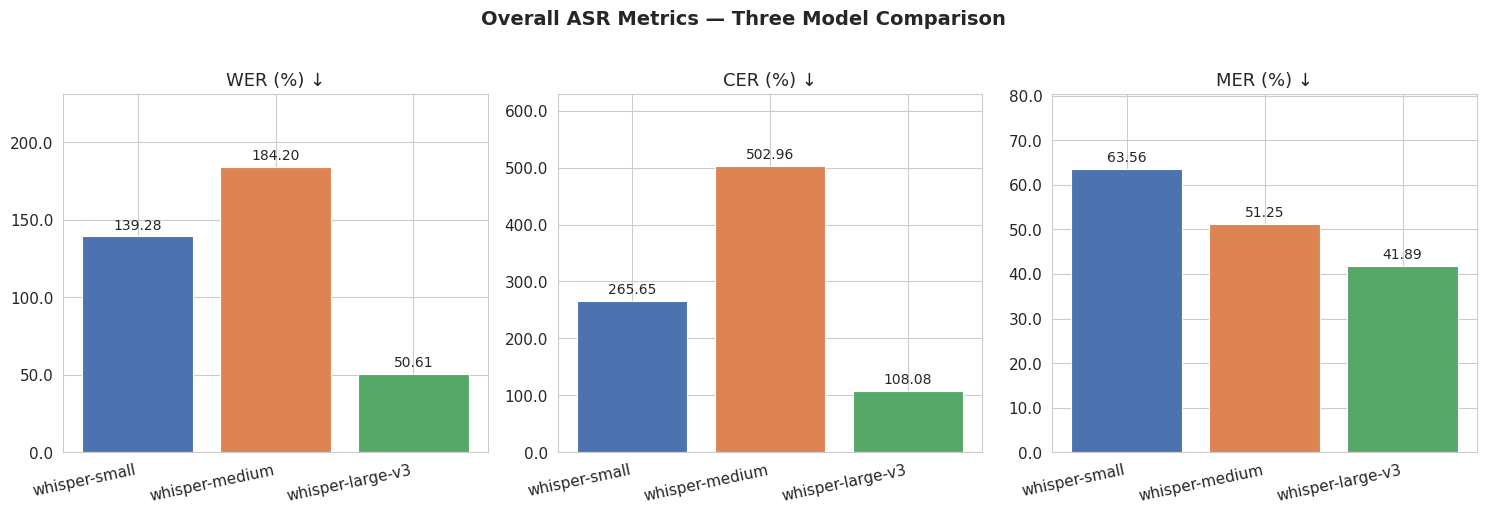

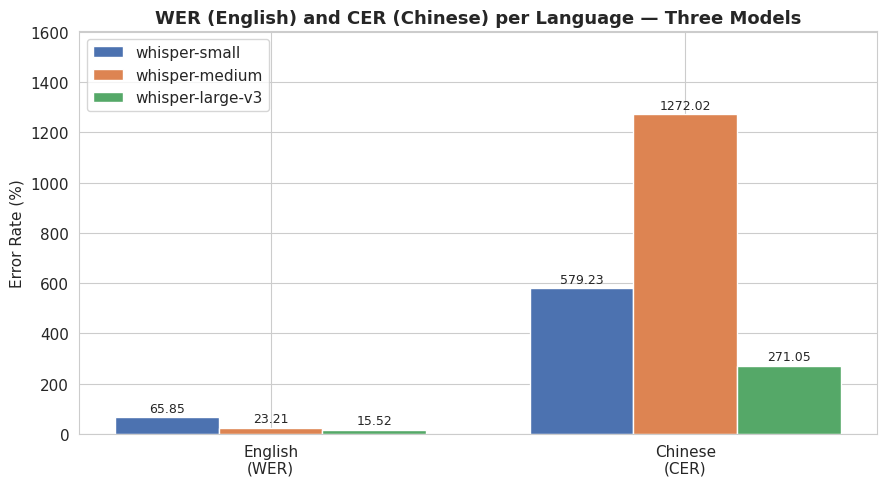

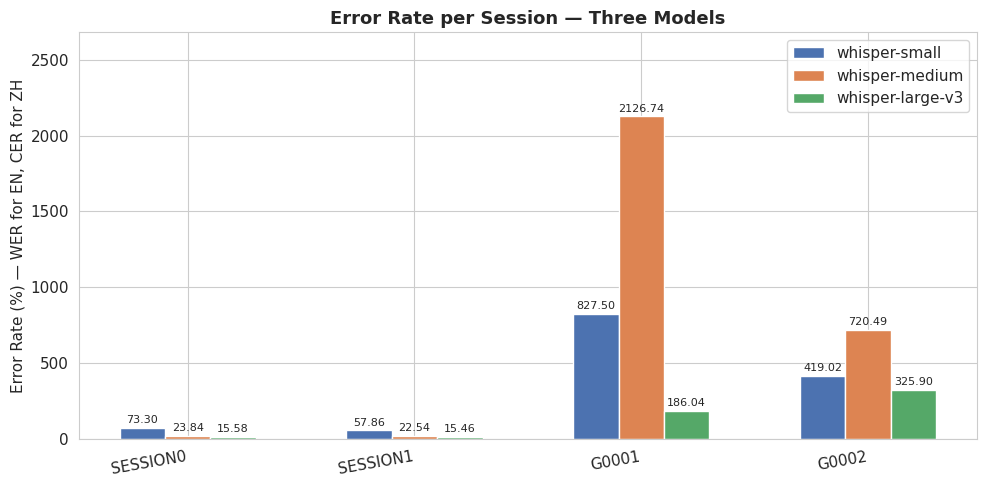

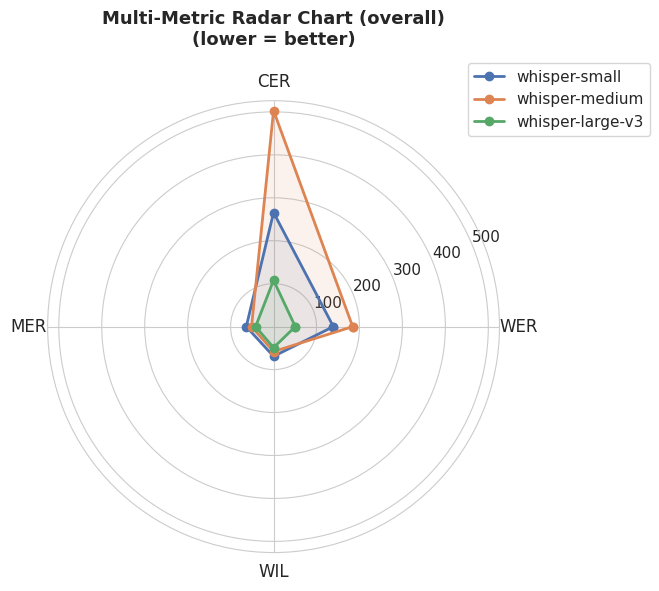

/tmp/ipykernel_2715/680423986.py:122: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_NAMES, rotation=12, ha='right')
/tmp/ipykernel_2715/680423986.py:122: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_NAMES, rotation=12, ha='right')
/tmp/ipykernel_2715/680423986.py:122: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_NAMES, rotation=12, ha='right')


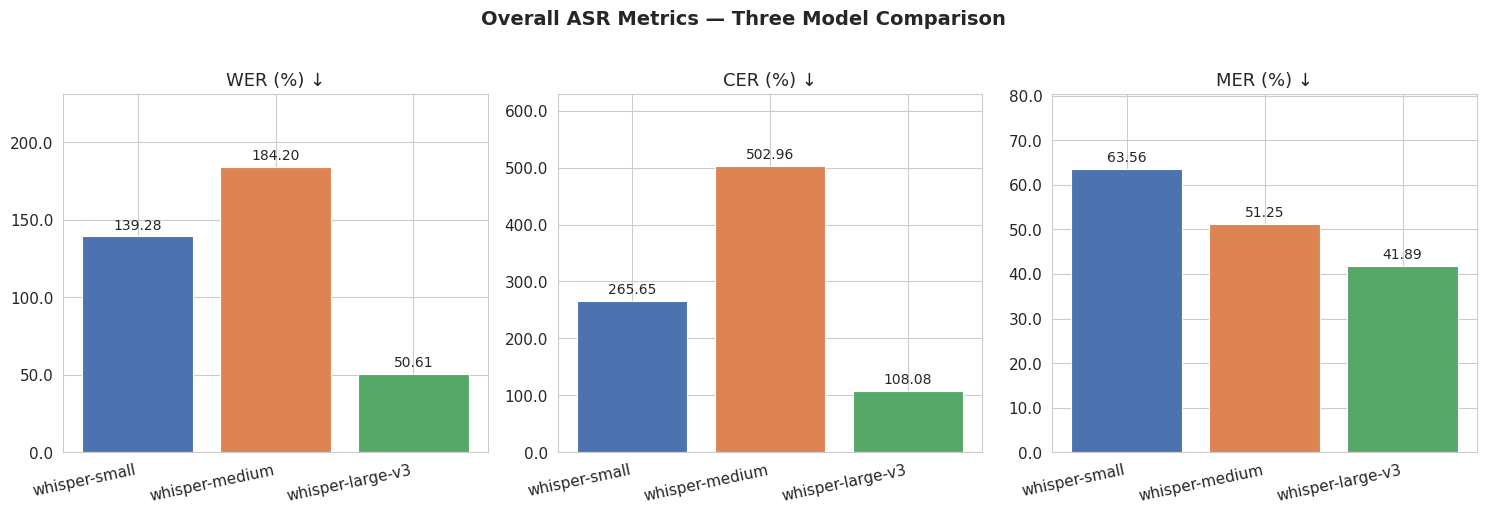

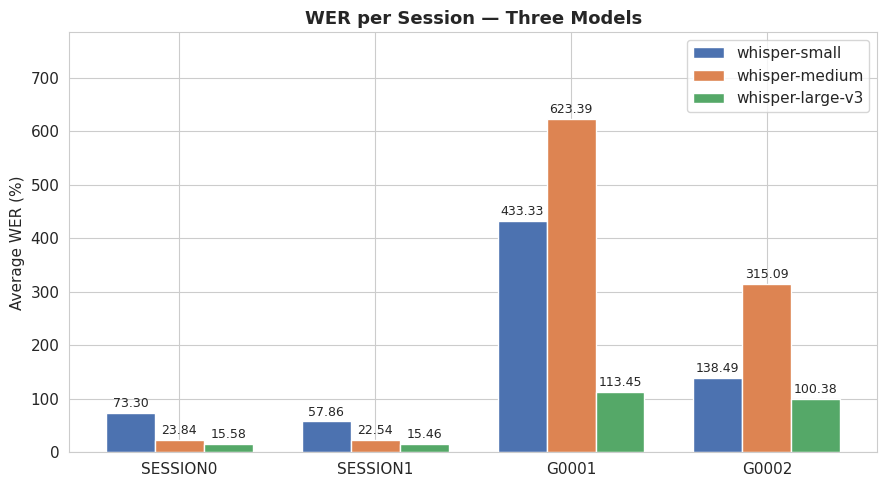

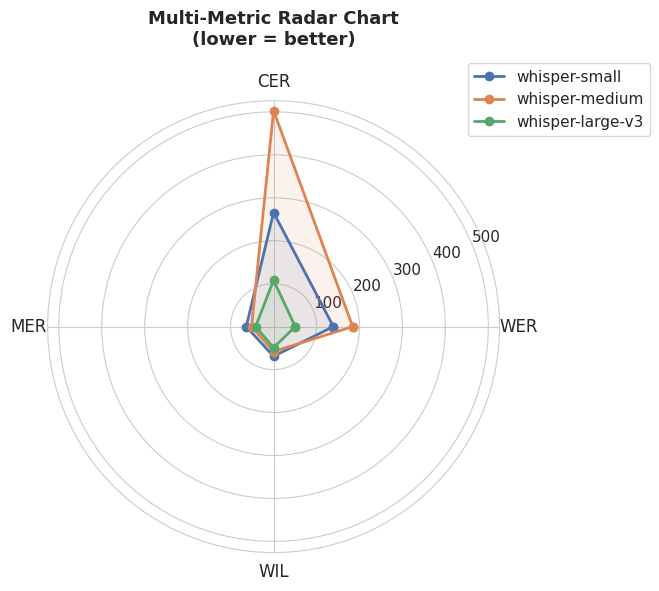

In [ ]:
# ── Cell 7: Visualisations ── Part 1: Bar charts & radar ──

MODEL_NAMES  = [mc['name'] for mc in MODEL_CONFIGS if mc['name'] in all_model_results]
PALETTE      = ['#4C72B0', '#DD8452', '#55A868']   # blue, orange, green
MODEL_COLORS = dict(zip(MODEL_NAMES, PALETTE))

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11})

# ── 1a: Overall WER / CER / MER side-by-side bars ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
overall_sorted = summary_df[summary_df['scope'] == 'ALL'].set_index('model')

for ax, (col, label) in zip(axes, [('avg_wer', 'WER (%) ↓'), ('avg_cer', 'CER (%) ↓'), ('avg_mer', 'MER (%) ↓')]):
    vals   = [overall_sorted.loc[m, col] if m in overall_sorted.index else 0 for m in MODEL_NAMES]
    colors = [MODEL_COLORS[m] for m in MODEL_NAMES]
    bars   = ax.bar(MODEL_NAMES, vals, color=colors, edgecolor='white', linewidth=0.8)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=10)
    ax.set_title(label)
    ax.set_ylim(0, max(vals) * 1.25 + 1)
    ax.set_xticklabels(MODEL_NAMES, rotation=12, ha='right')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

fig.suptitle('Overall ASR Metrics — Three Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'plot_01_overall_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()


# ── 1b: Per-language WER & CER bar chart ──
lang_scopes  = ['lang:en', 'lang:zh']
lang_labels  = ['English\n(WER)', 'Chinese\n(CER)']
lang_metrics = ['avg_wer', 'avg_cer']
x      = np.arange(len(lang_scopes))
width  = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
for i, m in enumerate(MODEL_NAMES):
    vals = []
    for scope, metric in zip(lang_scopes, lang_metrics):
        row = summary_df[(summary_df['model'] == m) & (summary_df['scope'] == scope)]
        vals.append(float(row[metric].values[0]) if not row.empty else 0.0)
    offset = (i - 1) * width
    bars   = ax.bar(x + offset, vals, width, label=m, color=MODEL_COLORS[m], edgecolor='white')
    ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(lang_labels, ha='center')
ax.set_ylabel('Error Rate (%)')
ax.set_title('WER (English) and CER (Chinese) per Language — Three Models', fontweight='bold')
ax.legend()
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'plot_02_per_language_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()


# ── 1c: Per-session error rate grouped bar chart ──
sessions = [sc['session'] for sc in SESSION_CONFIGS]
x        = np.arange(len(sessions))
width    = 0.20
fig, ax  = plt.subplots(figsize=(max(10, len(sessions)*2.5), 5))
for i, m in enumerate(MODEL_NAMES):
    vals = []
    for sess in sessions:
        row       = summary_df[(summary_df['model'] == m) & (summary_df['scope'] == sess)]
        sess_lang = next((sc['language'] for sc in SESSION_CONFIGS if sc['session'] == sess), 'en')
        metric    = 'avg_cer' if sess_lang == 'zh' else 'avg_wer'
        vals.append(float(row[metric].values[0]) if not row.empty else 0.0)
    offset = (i - (len(MODEL_NAMES)-1)/2) * width
    bars   = ax.bar(x + offset, vals, width, label=m, color=MODEL_COLORS[m], edgecolor='white')
    ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(sessions, rotation=10, ha='right')
ax.set_ylabel('Error Rate (%) — WER for EN, CER for ZH')
ax.set_title('Error Rate per Session — Three Models', fontweight='bold')
ax.legend()
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'plot_03_per_session_error_rate.png'), dpi=150, bbox_inches='tight')
plt.show()


# ── 1d: Radar chart ──
radar_metrics = ['avg_wer', 'avg_cer', 'avg_mer', 'avg_wil']
radar_labels  = ['WER', 'CER', 'MER', 'WIL']
N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
overall_sorted = summary_df[summary_df['scope'] == 'ALL'].set_index('model')
for m in MODEL_NAMES:
    if m not in overall_sorted.index: continue
    row  = overall_sorted.loc[m]
    vals = [float(row[c]) for c in radar_metrics] + [float(row[radar_metrics[0]])]
    ax.plot(angles, vals, 'o-', linewidth=2, label=m, color=MODEL_COLORS[m])
    ax.fill(angles, vals, alpha=0.10, color=MODEL_COLORS[m])
ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=12)
ax.set_title('Multi-Metric Radar Chart (overall)\n(lower = better)', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'plot_04_radar.png'), dpi=150, bbox_inches='tight')
plt.show()
# ── Cell 7: Visualisations ── Part 1: Bar charts & radar ──

MODEL_NAMES  = [mc['name'] for mc in MODEL_CONFIGS if mc['name'] in all_model_results]
PALETTE      = ['#4C72B0', '#DD8452', '#55A868']   # blue, orange, green
MODEL_COLORS = dict(zip(MODEL_NAMES, PALETTE))

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11})

# ── 1a: Overall WER / CER / MER side-by-side bars ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
overall_sorted = summary_df[summary_df['scope'] == 'ALL'].set_index('model')

for ax, (col, label) in zip(axes, [('avg_wer', 'WER (%) ↓'), ('avg_cer', 'CER (%) ↓'), ('avg_mer', 'MER (%) ↓')]):
    vals   = [overall_sorted.loc[m, col] if m in overall_sorted.index else 0 for m in MODEL_NAMES]
    colors = [MODEL_COLORS[m] for m in MODEL_NAMES]
    bars   = ax.bar(MODEL_NAMES, vals, color=colors, edgecolor='white', linewidth=0.8)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=10)
    ax.set_title(label)
    ax.set_ylim(0, max(vals) * 1.25 + 1)
    ax.set_xticklabels(MODEL_NAMES, rotation=12, ha='right')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

fig.suptitle('Overall ASR Metrics — Three Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'plot_01_overall_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()


# ── 1b: Per-session WER grouped bar chart ──
sessions = [sc['session'] for sc in SESSION_CONFIGS]
x        = np.arange(len(sessions))
width    = 0.25
fig, ax  = plt.subplots(figsize=(9, 5))

for i, m in enumerate(MODEL_NAMES):
    vals = []
    for sess in sessions:
        row = summary_df[(summary_df['model'] == m) & (summary_df['scope'] == sess)]
        vals.append(float(row['avg_wer'].values[0]) if not row.empty else 0.0)
    offset = (i - 1) * width
    bars   = ax.bar(x + offset, vals, width, label=m, color=MODEL_COLORS[m], edgecolor='white')
    ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(sessions)
ax.set_ylabel('Average WER (%)')
ax.set_title('WER per Session — Three Models', fontweight='bold')
ax.legend()
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'plot_02_per_session_wer.png'), dpi=150, bbox_inches='tight')
plt.show()


# ── 1c: Radar chart — multi-metric model comparison ──
radar_metrics = ['avg_wer', 'avg_cer', 'avg_mer', 'avg_wil']
radar_labels  = ['WER', 'CER', 'MER', 'WIL']
N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for m in MODEL_NAMES:
    row = overall_sorted.loc[m] if m in overall_sorted.index else None
    if row is None: continue
    vals = [float(row[c]) for c in radar_metrics] + [float(row[radar_metrics[0]])]
    ax.plot(angles, vals, 'o-', linewidth=2, label=m, color=MODEL_COLORS[m])
    ax.fill(angles, vals, alpha=0.10, color=MODEL_COLORS[m])

ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=12)
ax.set_title('Multi-Metric Radar Chart\n(lower = better)', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'plot_03_radar.png'), dpi=150, bbox_inches='tight')
plt.show()

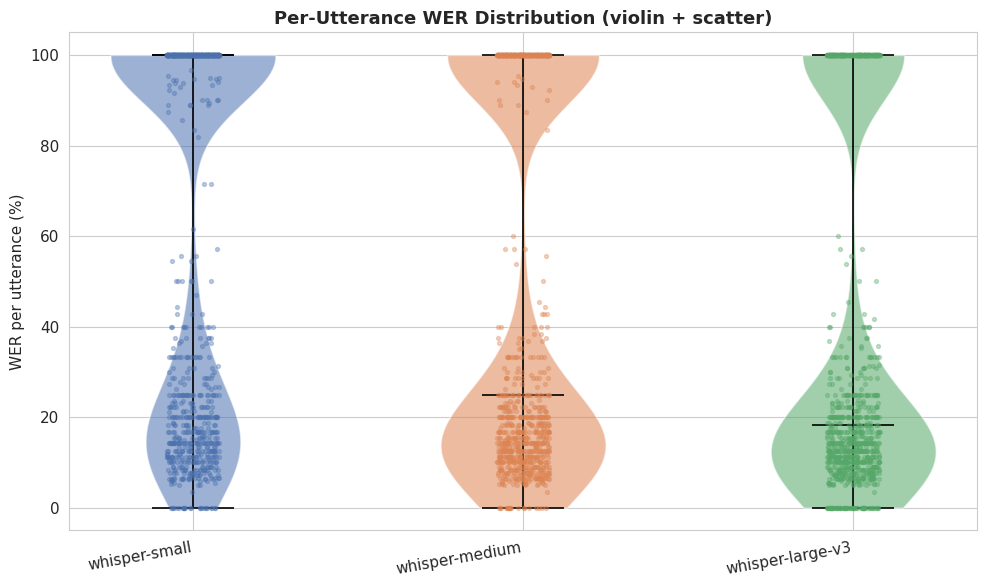

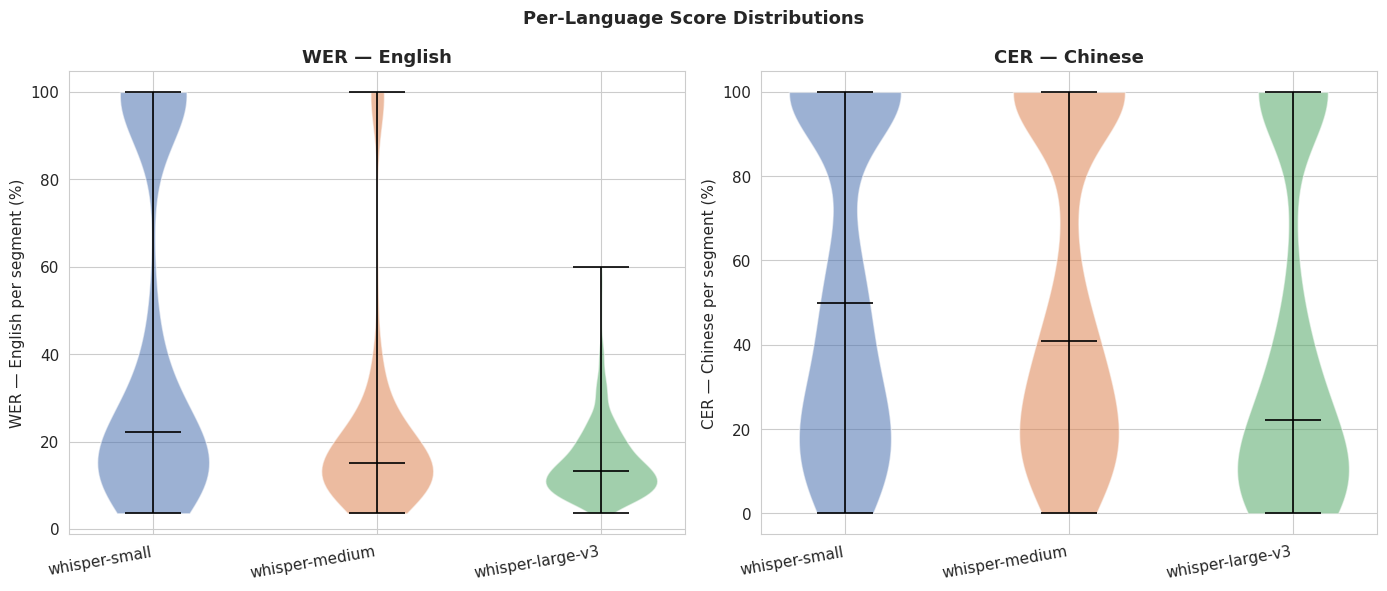

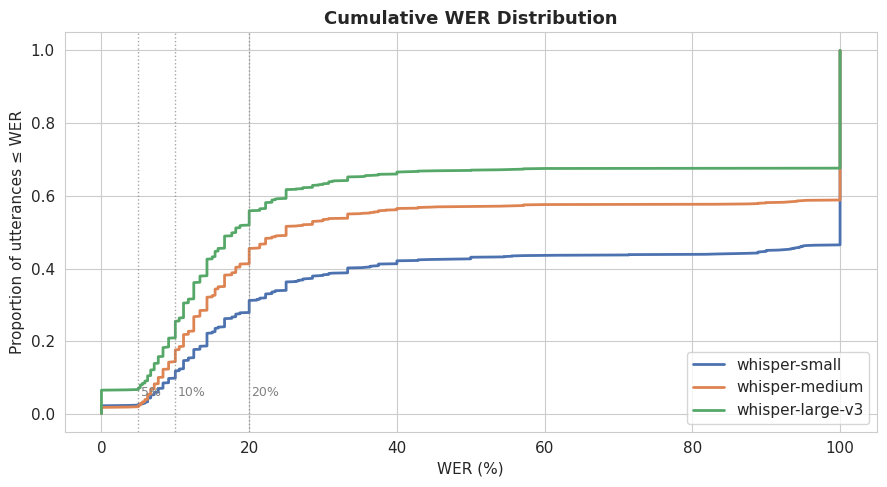

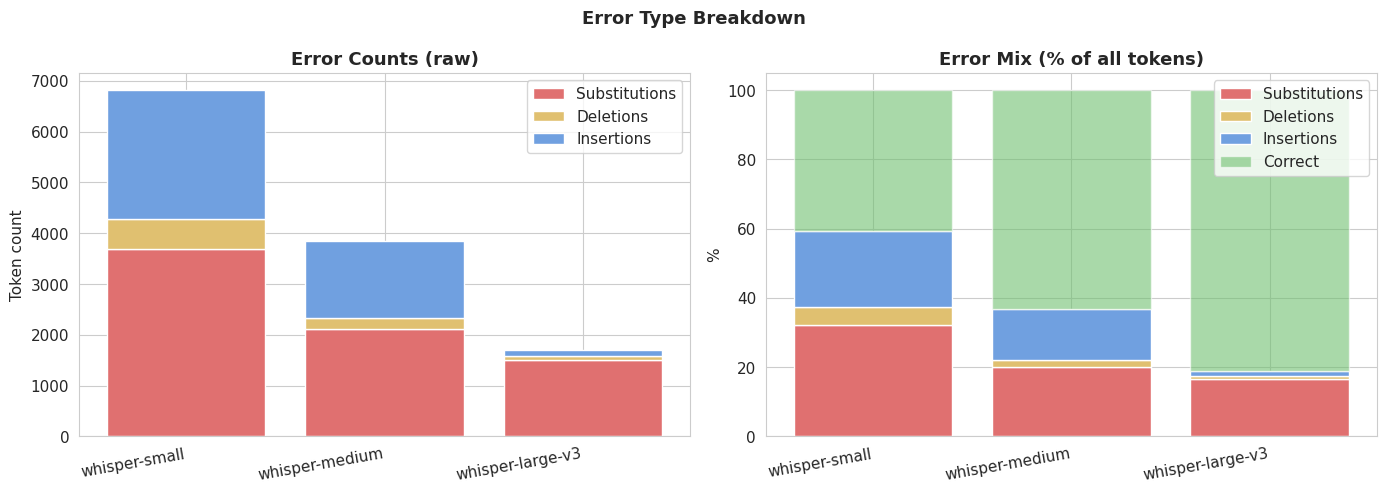

In [ ]:
# ── Cell 8: Visualisations ── Part 2: WER distributions & error breakdown ──

# ── 2a: Per-utterance WER violin + box plot ──
fig, ax = plt.subplots(figsize=(10, 6))
plot_data  = [all_model_results[m]['wer'].clip(upper=100).values for m in MODEL_NAMES]
colors_rgb = [MODEL_COLORS[m] for m in MODEL_NAMES]

vp = ax.violinplot(plot_data, positions=range(len(MODEL_NAMES)), showmedians=True, showextrema=True)
for i, (pc, col) in enumerate(zip(vp['bodies'], colors_rgb)):
    pc.set_facecolor(col)
    pc.set_alpha(0.55)
for part in ['cmedians', 'cmins', 'cmaxes', 'cbars']:
    vp[part].set_color('black')
    vp[part].set_linewidth(1.2)

# Overlay individual points (jittered)
rng = np.random.default_rng(42)
for i, (vals, col) in enumerate(zip(plot_data, colors_rgb)):
    jitter = rng.uniform(-0.08, 0.08, size=len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, s=8, alpha=0.35, color=col, zorder=3)

ax.set_xticks(range(len(MODEL_NAMES)))
ax.set_xticklabels(MODEL_NAMES, rotation=10, ha='right')
ax.set_ylabel('WER per utterance (%)')
ax.set_title('Per-Utterance WER Distribution (violin + scatter)', fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'plot_04_wer_violin.png'), dpi=150, bbox_inches='tight')
plt.show()


# ── 2a-ii: Per-language score distributions ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (lang, metric, label) in zip(axes, [('en', 'wer', 'WER — English'), ('zh', 'cer', 'CER — Chinese')]):
    lang_data  = [all_model_results[m][all_model_results[m]['language']==lang][metric].clip(upper=100).values
                  for m in MODEL_NAMES]
    active_idx = [i for i, d in enumerate(lang_data) if len(d) > 0]
    active_dat = [lang_data[i] for i in active_idx]
    if not active_dat:
        ax.set_title(f'{label} — no data'); continue
    vp = ax.violinplot(active_dat, positions=active_idx, showmedians=True)
    for pc, col in zip(vp['bodies'], [MODEL_COLORS[MODEL_NAMES[i]] for i in active_idx]):
        pc.set_facecolor(col); pc.set_alpha(0.55)
    for part in ['cmedians', 'cmins', 'cmaxes', 'cbars']:
        vp[part].set_color('black'); vp[part].set_linewidth(1.2)
    ax.set_xticks(range(len(MODEL_NAMES)))
    ax.set_xticklabels(MODEL_NAMES, rotation=10, ha='right')
    ax.set_ylabel(f'{label} per segment (%)')
    ax.set_title(label, fontweight='bold')
fig.suptitle('Per-Language Score Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'plot_04b_per_language_violin.png'), dpi=150, bbox_inches='tight')
plt.show()


# ── 2b: WER cumulative distribution (CDF) ──
fig, ax = plt.subplots(figsize=(9, 5))
for m in MODEL_NAMES:
    wers_sorted = np.sort(all_model_results[m]['wer'].clip(upper=100).values)
    cdf         = np.arange(1, len(wers_sorted) + 1) / len(wers_sorted)
    ax.plot(wers_sorted, cdf, label=m, linewidth=2, color=MODEL_COLORS[m])

ax.axvline(x=5,  color='grey', linestyle=':', linewidth=1, alpha=0.7)
ax.axvline(x=10, color='grey', linestyle=':', linewidth=1, alpha=0.7)
ax.axvline(x=20, color='grey', linestyle=':', linewidth=1, alpha=0.7)
ax.text(5.3, 0.05, '5%', fontsize=9, color='grey')
ax.text(10.3, 0.05, '10%', fontsize=9, color='grey')
ax.text(20.3, 0.05, '20%', fontsize=9, color='grey')
ax.set_xlabel('WER (%)')
ax.set_ylabel('Proportion of utterances ≤ WER')
ax.set_title('Cumulative WER Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'plot_05_wer_cdf.png'), dpi=150, bbox_inches='tight')
plt.show()


# ── 2c: Stacked error-type breakdown ──
err_overall = summary_df[summary_df['scope'] == 'ALL'].set_index('model')
subs  = [int(err_overall.loc[m, 'total_substitutions']) if m in err_overall.index else 0 for m in MODEL_NAMES]
dels  = [int(err_overall.loc[m, 'total_deletions'])     if m in err_overall.index else 0 for m in MODEL_NAMES]
ins   = [int(err_overall.loc[m, 'total_insertions'])    if m in err_overall.index else 0 for m in MODEL_NAMES]
hits  = [int(err_overall.loc[m, 'total_hits'])          if m in err_overall.index else 0 for m in MODEL_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
ax = axes[0]
x  = np.arange(len(MODEL_NAMES))
b1 = ax.bar(x, subs, label='Substitutions', color='#e07070')
b2 = ax.bar(x, dels, bottom=subs, label='Deletions', color='#e0c070')
b3 = ax.bar(x, ins,  bottom=np.array(subs)+np.array(dels), label='Insertions', color='#70a0e0')
ax.set_xticks(x)
ax.set_xticklabels(MODEL_NAMES, rotation=10, ha='right')
ax.set_title('Error Counts (raw)', fontweight='bold')
ax.set_ylabel('Token count')
ax.legend()

# Normalised %
ax = axes[1]
totals = np.array(subs) + np.array(dels) + np.array(ins) + np.array(hits)
totals = np.where(totals == 0, 1, totals)   # avoid div/0
ax.bar(x, np.array(subs)/totals*100, label='Substitutions', color='#e07070')
ax.bar(x, np.array(dels)/totals*100, bottom=np.array(subs)/totals*100, label='Deletions', color='#e0c070')
ax.bar(x, np.array(ins)/totals*100,
       bottom=(np.array(subs)+np.array(dels))/totals*100, label='Insertions', color='#70a0e0')
ax.bar(x, np.array(hits)/totals*100,
       bottom=(np.array(subs)+np.array(dels)+np.array(ins))/totals*100, label='Correct', color='#70c070', alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(MODEL_NAMES, rotation=10, ha='right')
ax.set_title('Error Mix (% of all tokens)', fontweight='bold')
ax.set_ylabel('%')
ax.legend()

fig.suptitle('Error Type Breakdown', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'plot_06_error_breakdown.png'), dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2715/3652053919.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_NAMES, rotation=10, ha='right')


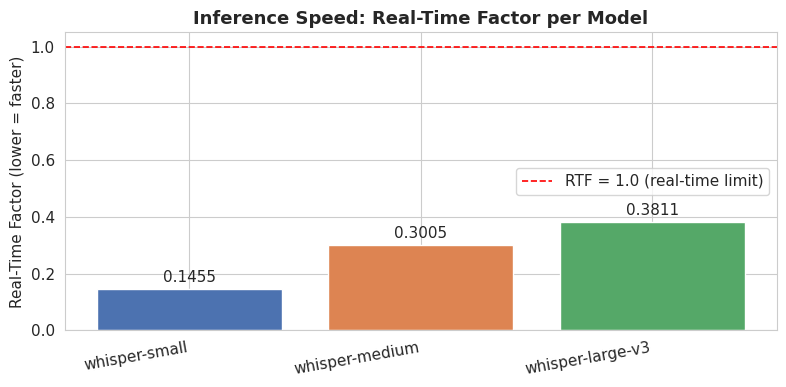

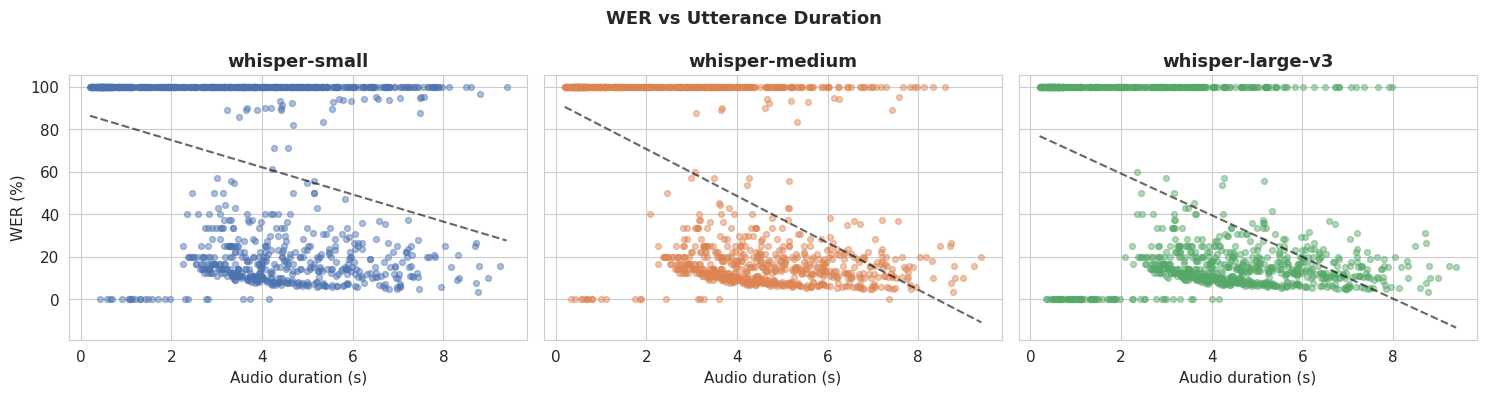

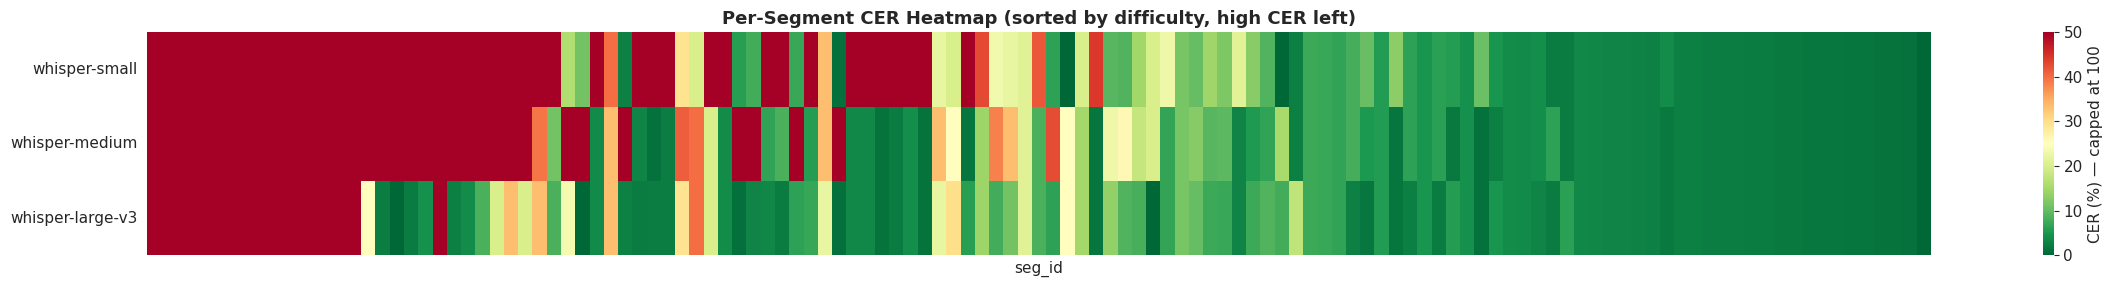

In [ ]:
# ── Cell 9: Visualisations ── Part 3: Inference speed & WER vs duration ──

# ── 3a: Real-time factor (RTF) bar chart ──
rtf_vals = [float(summary_df[(summary_df['model'] == m) & (summary_df['scope'] == 'ALL')]['rtf'].values[0])
            for m in MODEL_NAMES]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(MODEL_NAMES, rtf_vals, color=[MODEL_COLORS[m] for m in MODEL_NAMES], edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.2, label='RTF = 1.0 (real-time limit)')
ax.set_ylabel('Real-Time Factor (lower = faster)')
ax.set_title('Inference Speed: Real-Time Factor per Model', fontweight='bold')
ax.set_xticklabels(MODEL_NAMES, rotation=10, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'plot_07_rtf.png'), dpi=150, bbox_inches='tight')
plt.show()


# ── 3b: WER vs audio duration scatter (per model) ──
fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(5 * len(MODEL_NAMES), 4), sharey=True)
for ax, m in zip(axes, MODEL_NAMES):
    df = all_model_results[m]
    ax.scatter(df['audio_dur_sec'], df['wer'].clip(upper=100), alpha=0.45, s=18, color=MODEL_COLORS[m])
    # Trend line
    if len(df) > 3:
        z = np.polyfit(df['audio_dur_sec'], df['wer'].clip(upper=100), 1)
        p = np.poly1d(z)
        xs = np.linspace(df['audio_dur_sec'].min(), df['audio_dur_sec'].max(), 100)
        ax.plot(xs, p(xs), color='black', linewidth=1.5, linestyle='--', alpha=0.6)
    ax.set_title(m, fontweight='bold')
    ax.set_xlabel('Audio duration (s)')
    if ax == axes[0]:
        ax.set_ylabel('WER (%)')

fig.suptitle('WER vs Utterance Duration', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'plot_08_wer_vs_duration.png'), dpi=150, bbox_inches='tight')
plt.show()


# ── 3c: Per-utterance WER heatmap (utterances × models) ──
# Clip WER for display readability
heat_data = pd.DataFrame({
    m: all_model_results[m].set_index('seg_id')['cer'].clip(upper=100)
    for m in MODEL_NAMES
}).fillna(100).T   # shape: (models, utterances)

# Sort utterances by mean WER across models for a readable heatmap
utt_order   = heat_data.mean(axis=0).sort_values(ascending=False).index
heat_sorted = heat_data[utt_order]

# Downsample if too many utterances
max_cols = 120
if heat_sorted.shape[1] > max_cols:
    step = heat_sorted.shape[1] // max_cols
    heat_sorted = heat_sorted.iloc[:, ::step]

fig, ax = plt.subplots(figsize=(min(24, heat_sorted.shape[1] * 0.18 + 2), 3))
sns.heatmap(
    heat_sorted, ax=ax, cmap='RdYlGn_r',
    vmin=0, vmax=50, linewidths=0,
    cbar_kws={'label': 'CER (%) — capped at 100'},
    xticklabels=False,
)
ax.set_title('Per-Segment CER Heatmap (sorted by difficulty, high CER left)', fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'plot_09_wer_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2715/2977818744.py:41: UserWarning: Glyph 21999 (\N{CJK UNIFIED IDEOGRAPH-55EF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2715/2977818744.py:42: UserWarning: Glyph 21999 (\N{CJK UNIFIED IDEOGRAPH-55EF}) missing from font(s) DejaVu Sans.
  plt.savefig(str(OUTPUT_DIR / 'plot_10_substitution_pairs.png'), dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21999 (\N{CJK UNIFIED IDEOGRAPH-55EF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


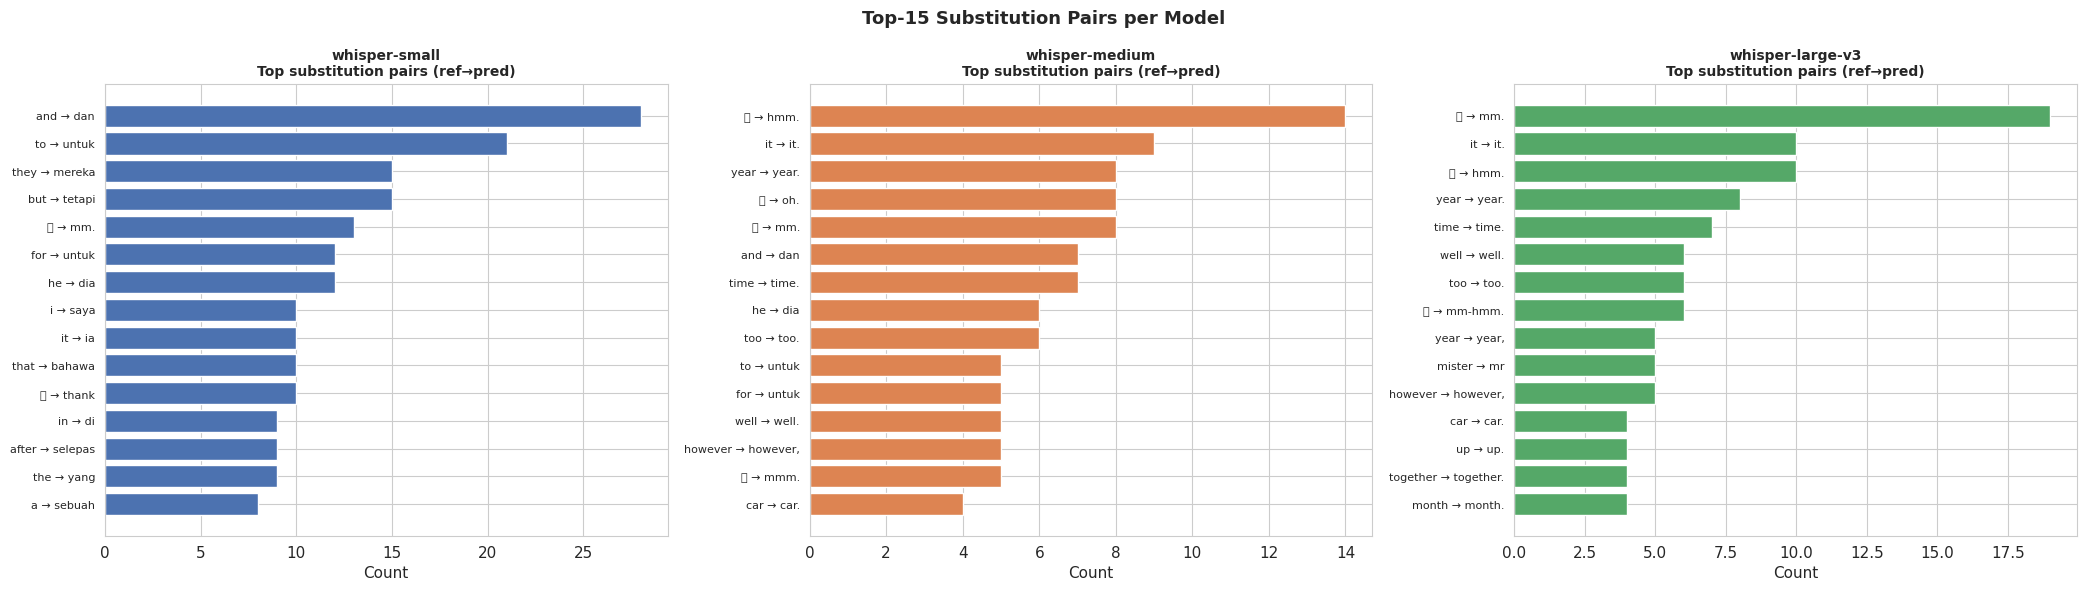

In [ ]:
# ── Cell 10: Visualisations ── Part 4: Substitution confusion heatmap ──

TOP_N_SUBS = 15
fig, axes  = plt.subplots(1, len(MODEL_NAMES), figsize=(7 * len(MODEL_NAMES), 6), sharey=False)
if len(MODEL_NAMES) == 1:
    axes = [axes]

for ax, m in zip(axes, MODEL_NAMES):
    df  = all_model_results[m]
    sub_counter = Counter()

    for _, row in df.iterrows():
        ref_words  = str(row['ref_norm']).split()
        pred_words = str(row['pred_norm']).split()
        # Walk through word-level alignment to find substitutions
        import difflib
        matcher = difflib.SequenceMatcher(None, ref_words, pred_words)
        for tag, i1, i2, j1, j2 in matcher.get_opcodes():
            if tag == 'replace':
                for r_w, p_w in zip(ref_words[i1:i2], pred_words[j1:j2]):
                    if r_w != p_w:
                        sub_counter[(r_w, p_w)] += 1

    if not sub_counter:
        ax.text(0.5, 0.5, 'No substitutions found', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(m)
        continue

    sub_df = pd.DataFrame(
        [{'ref': r, 'pred': p, 'count': c} for (r, p), c in sub_counter.most_common(TOP_N_SUBS)]
    )
    # Build label strings explicitly — avoids the tuple bug
    sub_df['ref_pred_pair'] = sub_df['ref'].astype(str) + ' → ' + sub_df['pred'].astype(str)

    ax.barh(sub_df['ref_pred_pair'][::-1], sub_df['count'][::-1], color=MODEL_COLORS[m])
    ax.set_xlabel('Count')
    ax.set_title(f'{m}\nTop substitution pairs (ref→pred)', fontweight='bold', fontsize=10)
    ax.tick_params(axis='y', labelsize=8)

fig.suptitle(f'Top-{TOP_N_SUBS} Substitution Pairs per Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'plot_10_substitution_pairs.png'), dpi=150, bbox_inches='tight')
plt.show()

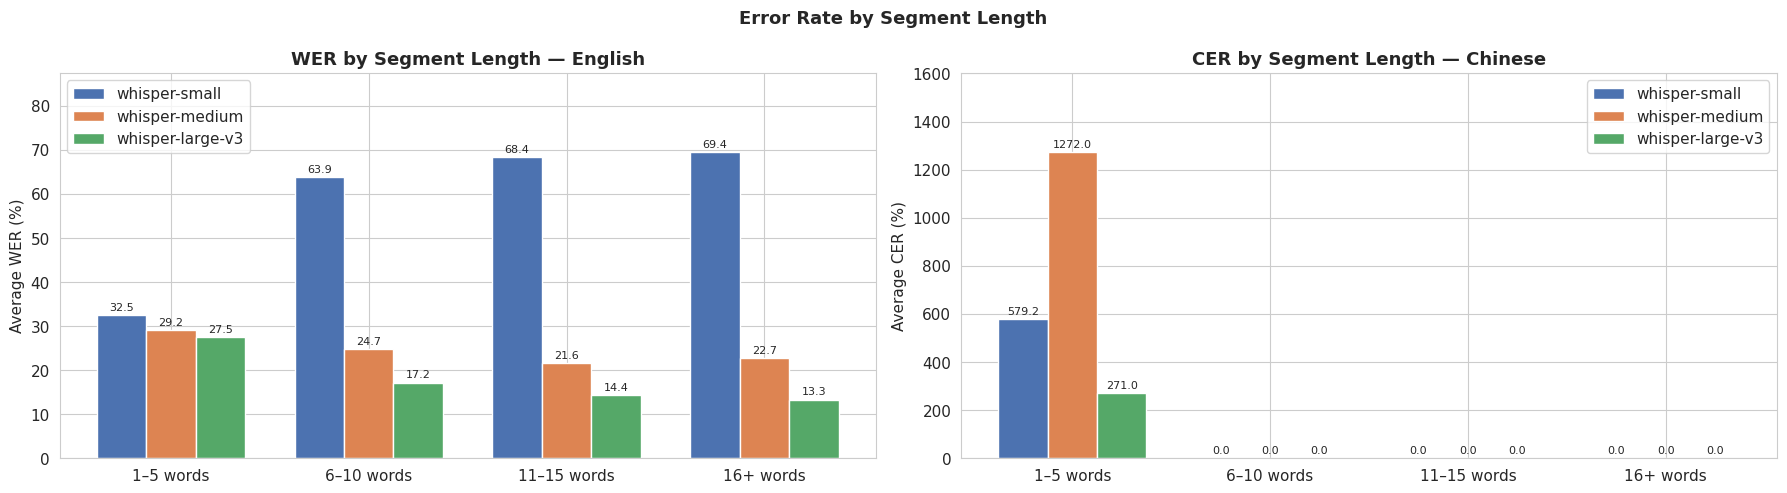

In [ ]:
# ── Cell 11: Visualisations ── Part 5: WER by utterance length bucket ──

def word_count_bucket(text: str) -> str:
    n = len((text or '').split())
    if n <= 5:  return '1–5 words'
    if n <= 10: return '6–10 words'
    if n <= 15: return '11–15 words'
    return '16+ words'


bucket_order = ['1–5 words', '6–10 words', '11–15 words', '16+ words']
bucket_rows  = []

for m in MODEL_NAMES:
    df = all_model_results[m].copy()
    df['bucket'] = df['ref_norm'].apply(word_count_bucket)
    grouped      = df.groupby('bucket')['wer'].mean()
    for b in bucket_order:
        bucket_rows.append({'model': m, 'bucket': b, 'avg_wer': grouped.get(b, float('nan'))})

bucket_df = pd.DataFrame(bucket_rows)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, (lang, metric_col, metric_label) in zip(axes, [('en', 'wer', 'WER'), ('zh', 'cer', 'CER')]):
    x     = np.arange(len(bucket_order))
    width = 0.25
    for i, m in enumerate(MODEL_NAMES):
        df_lang = all_model_results[m][all_model_results[m]['language'] == lang].copy()
        if df_lang.empty:
            continue
        df_lang['bucket'] = df_lang['ref_norm'].apply(word_count_bucket)
        grouped = df_lang.groupby('bucket')[metric_col].mean()
        vals    = [float(grouped.get(b, 0)) for b in bucket_order]
        offset  = (i - 1) * width
        bars    = ax.bar(x + offset, vals, width, label=m, color=MODEL_COLORS[m], edgecolor='white')
        ax.bar_label(bars, fmt='%.1f', padding=2, fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(bucket_order)
    ax.set_ylabel(f'Average {metric_label} (%)')
    ax.set_title(f'{metric_label} by Segment Length — {"English" if lang=="en" else "Chinese"}', fontweight='bold')
    ax.legend()
    ax.set_ylim(0, max(ax.get_ylim()[1] * 1.2, 1))
fig.suptitle('Error Rate by Segment Length', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'plot_11_error_by_length.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Cell 12: Large inference examples table ──
# Side-by-side REF vs each model prediction, sorted by worst average WER.

# Build wide comparison DataFrame
base = all_model_results[MODEL_NAMES[0]][['seg_id', 'session', 'language', 'ref', 'ref_display', 'ref_norm']].copy()
base = base.set_index('seg_id')

for m in MODEL_NAMES:
    df_m = all_model_results[m].set_index('seg_id')
    base[f'pred_{m}'] = df_m['pred_raw']
    base[f'wer_{m}']  = df_m['wer'].round(1)
    base[f'cer_{m}']  = df_m['cer'].round(1)

base['avg_wer'] = base[[f'wer_{m}' for m in MODEL_NAMES]].mean(axis=1)
base['avg_cer'] = base[[f'cer_{m}' for m in MODEL_NAMES]].mean(axis=1)
base = base.reset_index()

# Sort by avg_cer (better for mixed-language set), sample worst and best halves
n_half   = N_EXAMPLES // 2
worst    = base.nlargest(n_half, 'avg_cer')
best     = base.nsmallest(n_half, 'avg_cer')
examples = pd.concat([worst, best]).drop_duplicates('seg_id')

print(f'\n{"="*100}')
print(f'INFERENCE EXAMPLES — {len(examples)} segments  '
      f'({n_half} worst by avg CER + {n_half} best)')
print(f'{"="*100}')

sep_line = '-' * 100
for _, row in examples.iterrows():
    lang    = row['language']
    metric  = f'avg_cer' if lang == 'zh' else 'avg_wer'
    m_label = 'CER' if lang == 'zh' else 'WER'
    print(f'\n  SEG:  {row["seg_id"]}  |  [{lang.upper()}]  Session: {row["session"]}  |  Avg {m_label}: {row[metric]:.1f}%')
    print(f'  REF:  {row["ref_display"]}')
    for m in MODEL_NAMES:
        score_col = f'cer_{m}' if lang == 'zh' else f'wer_{m}'
        score_tag = f'{m_label}={row[score_col]:.1f}%'
        print(f'  {m:<22s} [{score_tag:>10s}]:  {row[f"pred_{m}"]}')
    print(sep_line)


INFERENCE EXAMPLES — 40 segments  (20 worst by avg CER + 20 best)

  SEG:  A0001_S001_0_G0001_000978301  |  [ZH]  Session: G0001  |  Avg CER: 53600.0%
  REF:  嗯
  whisper-small          [CER=300.0%]:  it.
  whisper-medium         [CER=159500.0%]:  Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very m

In [ ]:
# ── Cell 13: Worst utterances per model ──
# Shows the 15 hardest utterances for EACH model individually.

TOP_N_WORST = 15

for m in MODEL_NAMES:
    df    = all_model_results[m]
    worst = df.nlargest(TOP_N_WORST, 'cer')

    print(f'\n{"━"*90}')
    print(f'  {m.upper()} — {TOP_N_WORST} worst segments (by CER — preferred for Chinese)')
    print(f'{"━"*90}')
    for _, row in worst.iterrows():
        print(f'  [{row["seg_id"]}]  WER={row["wer"]:.1f}%  CER={row["cer"]:.1f}%  '
              f'S={row["substitutions"]} D={row["deletions"]} I={row["insertions"]}')
        print(f'    REF:  {row["ref"]}')
        print(f'    PRED: {row["pred_raw"]}')
        print()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  WHISPER-SMALL — 15 worst segments (by CER — preferred for Chinese)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [A0001_S001_0_G0002_001061666]  WER=100.0%  CER=75800.0%  S=1 D=0 I=0
    REF:  嗯
    PRED: MMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMM


Model agreement analysis
  Utterances ALL models get right  (WER ≤ 5.0%): 8 / 1118
  Utterances ALL models struggle   (WER ≥ 30.0%): 386 / 1118

  Per-model perfect (WER=0%) utterance counts:
    whisper-small         :   25 / 1118 (2.2%)
    whisper-medium        :   20 / 1118 (1.8%)
    whisper-large-v3      :   73 / 1118 (6.5%)


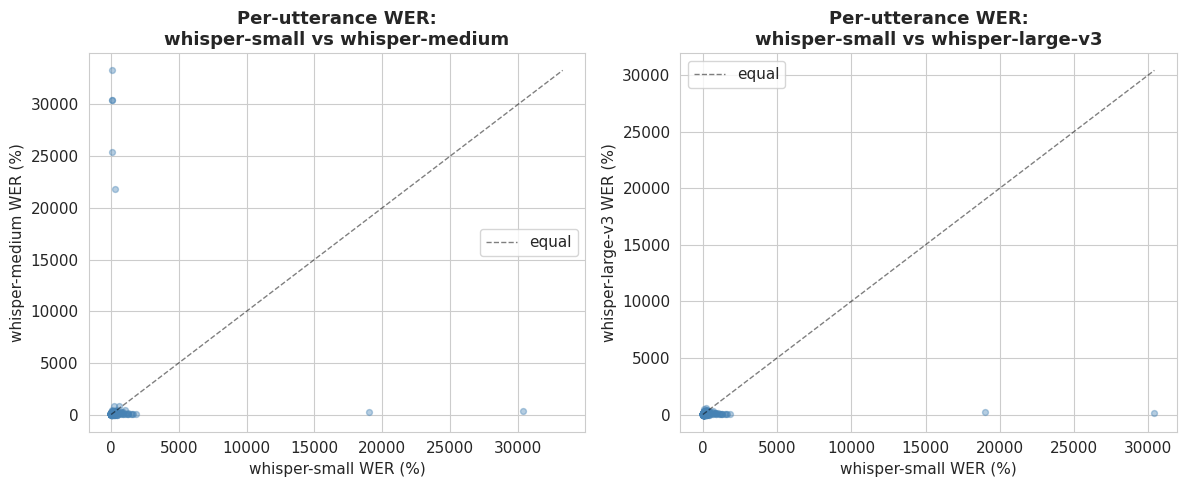

In [ ]:
# ── Cell 14: Model agreement analysis ──
# Which utterances does every model get right / wrong consistently?

WER_GOOD_THRESHOLD = 5.0    # utterance considered 'correct' if WER <= 5%
WER_BAD_THRESHOLD  = 30.0   # utterance considered 'hard' if WER >= 30%

agree_rows = []
for utt_id in [seg['seg_id'] for seg in all_segments]:
    wer_vals = {}
    for m in MODEL_NAMES:
        df_m = all_model_results[m]
        row  = df_m[df_m['seg_id'] == utt_id]
        if row.empty: continue
        wer_vals[m] = float(row['wer'].values[0])
    if len(wer_vals) < len(MODEL_NAMES):
        continue
    all_good = all(v <= WER_GOOD_THRESHOLD for v in wer_vals.values())
    all_bad  = all(v >= WER_BAD_THRESHOLD  for v in wer_vals.values())
    agree_rows.append({'utt_id': utt_id, **wer_vals, 'all_good': all_good, 'all_bad': all_bad})

agree_df   = pd.DataFrame(agree_rows)
n_all_good = agree_df['all_good'].sum()
n_all_bad  = agree_df['all_bad'].sum()

print(f'\nModel agreement analysis')
print(f'  Utterances ALL models get right  (WER ≤ {WER_GOOD_THRESHOLD}%): {n_all_good} / {len(agree_df)}')
print(f'  Utterances ALL models struggle   (WER ≥ {WER_BAD_THRESHOLD}%): {n_all_bad} / {len(agree_df)}')

# Venn-like: per-model perfect utterance counts
print('\n  Per-model perfect (WER=0%) utterance counts:')
for m in MODEL_NAMES:
    n_perfect = (all_model_results[m]['wer'] == 0).sum()
    pct       = 100 * n_perfect / len(all_model_results[m])
    print(f'    {m:22s}: {n_perfect:4d} / {len(all_model_results[m])} ({pct:.1f}%)')

# Visualise: scatter WER of model1 vs model2
if len(MODEL_NAMES) >= 2:
    m1, m2 = MODEL_NAMES[0], MODEL_NAMES[1]
    fig, axes = plt.subplots(1, 2 if len(MODEL_NAMES) >= 3 else 1, figsize=(12, 5))
    ax_pairs = [(m1, m2), (m1, MODEL_NAMES[2])] if len(MODEL_NAMES) >= 3 else [(m1, m2)]
    axes = [axes] if not hasattr(axes, '__len__') else axes

    for ax, (ma, mb) in zip(axes, ax_pairs):
        xa = agree_df[ma].values
        xb = agree_df[mb].values
        ax.scatter(xa, xb, alpha=0.4, s=18, color='steelblue')
        lim = max(xa.max(), xb.max()) + 5
        ax.plot([0, lim], [0, lim], 'k--', linewidth=1, alpha=0.5, label='equal')
        ax.set_xlabel(f'{ma} WER (%)')
        ax.set_ylabel(f'{mb} WER (%)')
        ax.set_title(f'Per-utterance WER:\n{ma} vs {mb}', fontweight='bold')
        ax.legend()

    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / 'plot_12_model_agreement.png'), dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# ── Cell 15: Full ranked examples table (all segments, sorted by avg CER) ──
# Prints ALL segments with predictions from each model, ranked hardest → easiest.
# Useful for detailed error analysis or copy-paste into a report.

full_table = base.sort_values('avg_cer', ascending=False).reset_index(drop=True)

print(f'\n{"="*100}')
print(f'FULL INFERENCE TABLE — all {len(full_table)} segments, sorted hardest → easiest (by avg CER)')
print(f'{"="*100}')

for rank, (_, row) in enumerate(full_table.iterrows(), start=1):
    lang    = row['language']
    m_label = 'CER' if lang == 'zh' else 'WER'
    metric  = 'avg_cer' if lang == 'zh' else 'avg_wer'
    print(f'\n#{rank:04d}  {row["seg_id"]}  [{lang.upper()}]  [{row["session"]}]  Avg {m_label}: {row[metric]:.1f}%')
    print(f'  REF:  {row["ref_display"]}')
    for m in MODEL_NAMES:
        score_col = f'cer_{m}' if lang == 'zh' else f'wer_{m}'
        score_tag = f'{row[score_col]:.1f}%'
        print(f'  {m:<22s} [{score_tag:>6s}]  {row[f"pred_{m}"]}')
    if rank % 50 == 0:
        print(f'\n  ... ({rank}/{len(full_table)} shown) ...')


FULL INFERENCE TABLE — all 1118 segments, sorted hardest → easiest (by avg CER)

#0001  A0001_S001_0_G0001_000978301  [ZH]  [G0001]  Avg CER: 53600.0%
  REF:  嗯
  whisper-small          [300.0%]  it.
  whisper-medium         [159500.0%]  Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank you very much. Thank

In [ ]:
# ── Cell 16: Final summary & download ──

print('\n' + '═'*70)
print('  FINAL MODEL COMPARISON SUMMARY')
print('═'*70)

overall_final = summary_df[summary_df['scope'] == 'ALL'].set_index('model')
ranked        = overall_final.sort_values('avg_wer')

for rank, (m, row) in enumerate(ranked.iterrows(), start=1):
    print(f'\n  #{rank} {m}')
    print(f'      WER={row["avg_wer"]:.3f}%  CER={row["avg_cer"]:.3f}%  MER={row["avg_mer"]:.3f}%')
    print(f'      WIL={row["avg_wil"]:.3f}%  WIP={row["avg_wip"]:.3f}%  RTF={row["rtf"]:.4f}')
    print(f'      Errors: S={row["total_substitutions"]}  D={row["total_deletions"]}  I={row["total_insertions"]}')

print(f'\n  Best overall model (lowest WER): {ranked.index[0]}')
print('═'*70)

for lang_scope, metric, label in [('lang:en', 'avg_wer', 'English WER'), ('lang:zh', 'avg_cer', 'Chinese CER')]:
    lang_rows = summary_df[summary_df['scope'] == lang_scope].sort_values(metric)
    if lang_rows.empty:
        continue
    print(f'\n  {label} ranking:')
    for rank2, (_, r2) in enumerate(lang_rows.iterrows(), 1):
        print(f'    #{rank2} {r2["model"]:22s}  {label}={r2[metric]:.3f}%  n={r2["n_segs"]}')
print('═'*70)

# ── Save summary metrics JSON to output dir ──────────────────────────────────
import json as _json

summary_json_path = OUTPUT_DIR / 'summary_metrics.json'
summary_export = {}
for scope_key, scope_label in [('ALL', 'overall'), ('lang:en', 'english'), ('lang:zh', 'chinese')]:
    scope_rows = summary_df[summary_df['scope'] == scope_key]
    summary_export[scope_label] = []
    for _, row in scope_rows.iterrows():
        summary_export[scope_label].append({
            'model':               row['model'],
            'avg_wer':             float(row['avg_wer']),
            'avg_cer':             float(row['avg_cer']),
            'avg_mer':             float(row['avg_mer']),
            'avg_wil':             float(row['avg_wil']),
            'avg_wip':             float(row['avg_wip']),
            'rtf':                 float(row['rtf']),
            'n_segs':              int(row['n_segs']),
            'total_substitutions': int(row['total_substitutions']),
            'total_deletions':     int(row['total_deletions']),
            'total_insertions':    int(row['total_insertions']),
        })
summary_json_path.write_text(_json.dumps(summary_export, indent=2), encoding='utf-8')
print(f'Summary JSON saved: {summary_json_path}')

# ── Save per-session breakdown CSV ───────────────────────────────────────────
per_session_csv = OUTPUT_DIR / 'per_session_metrics.csv'
summary_df.to_csv(str(per_session_csv), index=False, encoding='utf-8')
print(f'Per-session metrics saved: {per_session_csv}')

# ── List all saved files ──────────────────────────────────────────────────────
plots = sorted(OUTPUT_DIR.glob('plot_*.png'))
print(f'\nSaved plots ({len(plots)}):')
for p in plots:
    print(f'  {p}')
print(f'\nFull results CSV:      {OUTPUT_CSV}')
print(f'Summary JSON:          {summary_json_path}')
print(f'Per-session CSV:       {per_session_csv}')
print(f'\nAll outputs saved to: {OUTPUT_DIR}')
if SAVE_TO_DRIVE:
    print('  ✓ Saved to Google Drive — safe even after runtime disconnects.')
else:
    print('  ⚠ Saved to Colab temp storage — download before disconnecting.')


══════════════════════════════════════════════════════════════════════
  FINAL MODEL COMPARISON SUMMARY
══════════════════════════════════════════════════════════════════════

  #1 whisper-large-v3
      WER=50.612%  CER=108.084%  MER=41.886%
      WIL=48.990%  WIP=51.010%  RTF=0.3811
      Errors: S=1498  D=90  I=121

  #2 whisper-small
      WER=139.276%  CER=265.650%  MER=63.562%
      WIL=69.173%  WIP=30.827%  RTF=0.1455
      Errors: S=3696  D=591  I=2531

  #3 whisper-medium
      WER=184.198%  CER=502.957%  MER=51.246%
      WIL=57.986%  WIP=42.014%  RTF=0.3005
      Errors: S=2113  D=214  I=1529

  Best overall model (lowest WER): whisper-large-v3
══════════════════════════════════════════════════════════════════════

  English WER ranking:
    #1 whisper-large-v3        English WER=15.519%  n=682
    #2 whisper-medium          English WER=23.215%  n=682
    #3 whisper-small           English WER=65.851%  n=682

  Chinese CER ranking:
    #1 whisper-large-v3        Chinese CER